<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/Copy_of_HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
from process_bank_churn import preprocess_data
import pandas as pd
raw_df = pd.read_csv("train.csv")
data = preprocess_data(raw_df)

In [2]:
X_train = data['train_inputs']
train_targets = data['train_targets']
X_val = data['val_inputs']
val_targets = data['val_targets']

In [3]:
X_train.head(5)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.478699,0.988516,0.599045,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.692913,0.984351,0.603819,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.005334,0.997112,0.653938,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.224348,0.997533,0.568019,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.815788,0.987805,0.658711,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

In [5]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

train_proba = knn.predict_proba(X_train)[:, 1]
val_proba = knn.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

print("Train AUROC:", train_auc)
print("Validation AUROC:", val_auc)

Train AUROC: 0.949635562629913
Validation AUROC: 0.850057274161465


Отримана модель є досить хорошою, оскільки показує AUROC = 0.85 на валідаційній вибірці, що свідчить про хорошу здатність розрізняти класи. Водночас AUROC на навчальній вибірці (0.95) значно вищий, ніж на валідаційній, що вказує на high variance (переобучення, overfitting). Модель дуже добре запам'ятала навчальні дані, але її якість на нових даних помітно нижча. Ознак high bias (недонавчання) немає, оскільки якість на навчальній вибірці є високою.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [6]:
params_knn = {"n_neighbors": np.arange(1, 25)}

knn_gs = GridSearchCV(
    estimator=knn,
    param_grid=params_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

knn_gs.fit(X_train, train_targets)

print("Best n_neighbors:", knn_gs.best_params_["n_neighbors"])
print("Best CV ROC_AUC:", knn_gs.best_score_)

knn_best = knn_gs.best_estimator_

train_auc = roc_auc_score(train_targets, knn_best.predict_proba(X_train)[:, 1])
val_auc = roc_auc_score(val_targets, knn_best.predict_proba(X_val)[:, 1])

print("Train AUROC:", train_auc)
print("Validation AUROC:", val_auc)

Best n_neighbors: 20
Best CV ROC_AUC: 0.8710410358154427
Train AUROC: 0.9133686631332583
Validation AUROC: 0.8791062487139034


In [ ]:
Модель стала кращою оскільки AUROC = 0.879 на валідаційній вибірці, що свідчить про ліпшу
здатність розрізняти класи. Також є ліпшою за дерево прийняття рішень з попереднього ДЗ

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [7]:
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    "max_depth": list(range(1, 21, 2)),
    "max_leaf_nodes": list(range(2, 11))
}

dt = DecisionTreeClassifier(random_state=42)
gs = GridSearchCV(dt, param_grid=param_grid, cv=3, scoring="roc_auc", n_jobs=-1)

gs.fit(X_train, train_targets)

print("Best params:", gs.best_params_)
print("Best CV ROC_AUC:", gs.best_score_)


dt_best = gs.best_estimator_

train_auc = roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])
val_auc = roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1])

print("Train AUROC:", train_auc)
print("Validation AUROC:", val_auc)

Best params: {'max_depth': 5, 'max_leaf_nodes': 10}
Best CV ROC_AUC: 0.9013929183420709
Train AUROC: 0.9014754782174744
Validation AUROC: 0.9002184649152891


Модель має плюс мінус такі ж значення Validation AUROC які я знайшла вручну в минулому ДЗ. Але звичайно, що з GridSearchCV це робиться набагато швидче

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [8]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [9]:
from sklearn.model_selection import RandomizedSearchCV
RANDOM_STATE = 42
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

dt_random_search.fit(X_train, train_targets)


print("Best params:", dt_random_search.best_params_)
print("Best CV ROC_AUC:", dt_random_search.best_score_)


dt_random_search_best = dt_random_search.best_estimator_

train_auc = roc_auc_score(
    train_targets,
    dt_random_search_best.predict_proba(X_train)[:, 1]
)
val_auc = roc_auc_score(
    val_targets,
    dt_random_search_best.predict_proba(X_val)[:, 1]
)

print("Train AUROC:", train_auc)
print("Validation AUROC:", val_auc)

Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best CV ROC_AUC: 0.910864318350194
Train AUROC: 0.9169275635848141
Validation AUROC: 0.9166204815145071


RandomizedSearchCV будує набагато складніщу модель ніж в завданні 3

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [10]:
from process_bank_churn import preprocess_new_data
test_df = pd.read_csv("test.csv")


X_test = preprocess_new_data(
    new_df=test_df,
    input_cols=data["input_cols"],
    scaler=data["scaler"],
    encoder=data["encoder"]
)


In [11]:
dt_random_search_best.fit(
    X_train,
    train_targets
)

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [13]:
predictions = dt_random_search_best.predict(X_test)

In [14]:
submission = pd.DataFrame(
    {
        "id": test_df["id"],
        "Exited": predictions
    }
)


# 6. Save submission.csv

submission.to_csv(
    "submission.csv",
    index=False
)


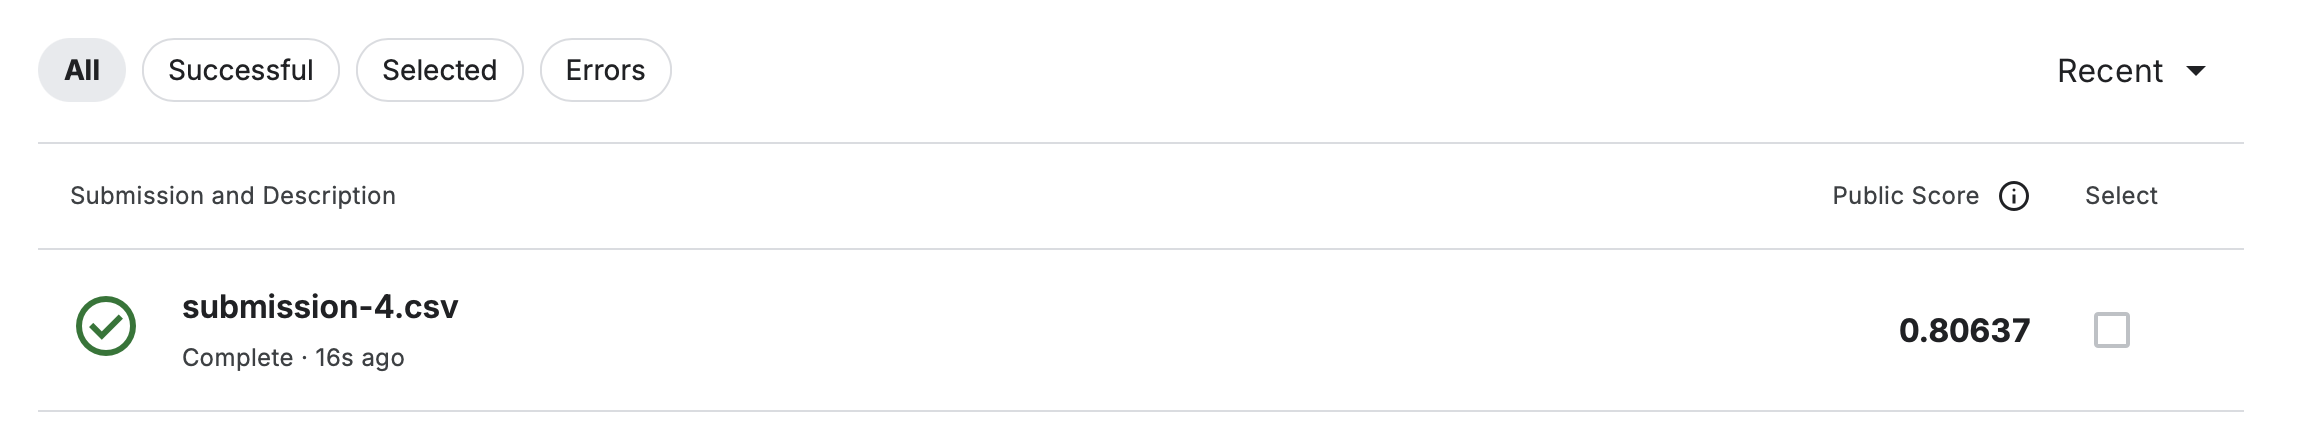